# Lattice Surgery on qLDPC Codes

Lean demo of `qldpc.circuits.surgery`:
- **§1–§2 Correctness on Steane [[7,1,3]]** — `timeline-svg` circuits + noiseless
  truth tables for single X̄ / Z̄ / Ȳ PPM and joint Z̄⊗Z̄ / X̄⊗X̄.
- **§3–§4 LER** — surgery vs memory on BB [[72, 12, 6]] (gross) and Cain `bb_18`
  [[248, 10, 18]]. Surgery **and** memory are averaged over X- and Z-basis
  initialization/measurement experiments (Cain et al. arXiv:2603.28627 App. D).

## §0 Setup

In [1]:
from __future__ import annotations

import time

import numpy as np
import sinter
import stim
import sympy
import matplotlib.pyplot as plt

from qldpc import codes, circuits, decoders
from qldpc.circuits.surgery import (
    build_gadget,
    build_bridge,
    build_single_ppm_circuit,
    build_joint_ppm_circuit,
    build_y_gadget,
    build_single_y_ppm_circuit,
    boost_gadget,
    cheeger_constant,
    keep_only_observable,
    logical_state_init,
    symplectic_logical_basis,
)
from qldpc.circuits.noise_model import DepolarizingNoiseModel
from qldpc.objects import Pauli

In [2]:
def raw_observables(circuit: stim.Circuit, shots: int) -> np.ndarray:
    """Compute raw ±1 observable values (XOR of designated measurements).

    Why not ``compile_detector_sampler(separate_observables=True)``?
    ──────────────────────────────────────────────────────────────────
      • ``compile_detector_sampler`` returns observable **flips relative to
        the noiseless reference**, i.e. ``actual XOR reference``. For a
        noiseless circuit, this is always 0 regardless of whether the
        underlying logical eigenvalue is +1 or −1. It's the right API for
        an LER sweep (we care about flips induced by noise), but it hides
        the sign of the logical outcome.

      • ``compile_sampler`` returns raw measurement records, from which we
        XOR the bits designated by each ``OBSERVABLE_INCLUDE`` line. The
        result IS the raw logical eigenvalue (0 ↔ +1, 1 ↔ −1), so the
        protocol's truth table — which initial state produces which sign —
        is directly visible. Use this API for noiseless correctness
        checks where the sign matters (truth tables, joint-parity tests).
    """
    sampler = circuit.compile_sampler()
    raw = sampler.sample(shots=shots).astype(np.uint8)
    n_meas = raw.shape[1]
    obs_lines = [ln for ln in str(circuit).splitlines() if ln.startswith("OBSERVABLE_INCLUDE")]
    cols = []
    for line in obs_lines:
        offsets = [int(t.strip("rec[]")) for t in line.split() if t.startswith("rec[")]
        meas_idx = [n_meas + off for off in offsets]
        cols.append(np.bitwise_xor.reduce(raw[:, meas_idx], axis=1))
    return np.stack(cols, axis=1)

## §1 Single-PPM — Steane [[7,1,3]]

Observable layout (Cain et al. arXiv:2603.28627 App. D experiment): obs0 =
frame-corrected block logical, obs1 = time-like L (Webster Eq. 1). Noiseless ⇒
obs0 == obs1; deterministic on commuting preps, genuine 50/50 on anticommuting.

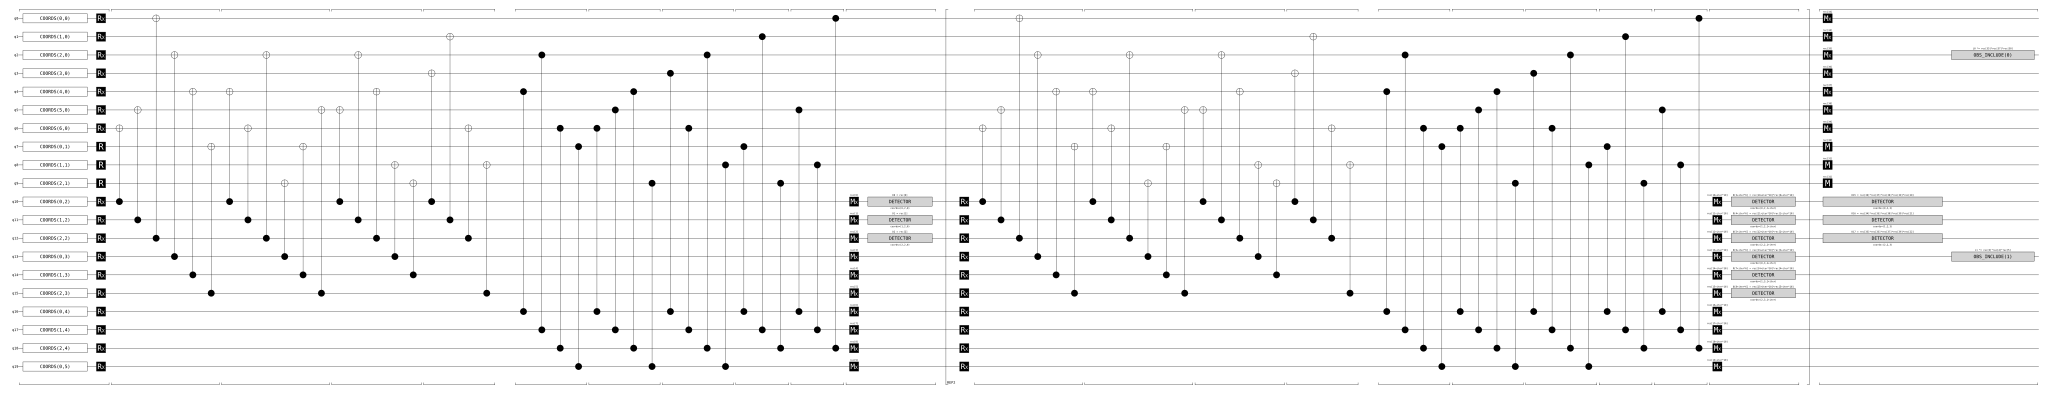

In [3]:
# Steane X̄ single-PPM circuit.
# timeline-svg lanes (QUBIT_COORDS y): 0 data · 1 Q' ancillas · 2 H_X ancillas ·
# 3 S_X' meas-checks · 4 H_Z ancillas · 5 S_Z' gauge-fix rows.
steane = codes.SteaneCode()
x_steane = np.asarray(steane.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
g_x = build_gadget(steane, x_steane, basis=Pauli.X)
build_single_ppm_circuit(g_x, rounds=3, noise_model=None, data_init="+", single_sector=True).diagram("timeline-svg")

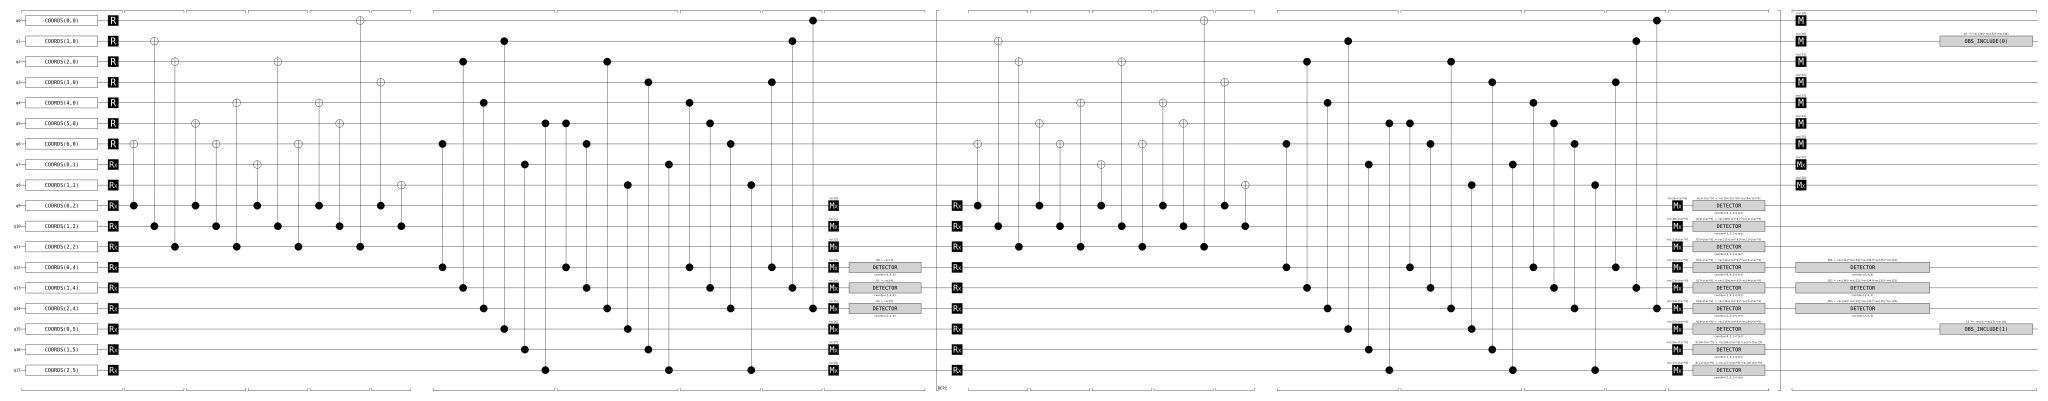

In [4]:
# Steane Z̄ single-PPM circuit (basis=Z: the S_X'/S_Z' lane roles swap).
z_steane = np.asarray(steane.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
g_z = build_gadget(steane, z_steane, basis=Pauli.Z)
build_single_ppm_circuit(g_z, rounds=3, noise_model=None, data_init="0").diagram("timeline-svg")

In [5]:
# Truth tables: scan the 4 CSS logical inits through the X̄- and Z̄-PPM.
# raw_observables (NOT the detector sampler) — see the §0 helper docstring.
SHOTS = 4000
for basis, gadget in ((Pauli.X, g_x), (Pauli.Z, g_z)):
    comm = ("+", "-") if basis is Pauli.X else ("0", "1")
    anti = ("0", "1") if basis is Pauli.X else ("+", "-")
    print(f"measure {basis}̄ :")
    print(f"{'data':>7} | {'expected':>8} | {'obs0 frac=1':>11} | obs0==obs1 | ok")
    for state in (*comm, *anti):
        deterministic = state in comm
        expected = float(state in ("-", "1")) if deterministic else 0.5
        circ = build_single_ppm_circuit(
            gadget,
            rounds=3,
            noise_model=None,
            data_init=logical_state_init(steane, state, log_idx=0),
        )
        obs = raw_observables(circ, SHOTS)
        rate = float(obs[:, 0].mean())
        agree = float((obs[:, 0] == obs[:, 1]).mean())
        ok = (rate == expected if deterministic else 0.4 < rate < 0.6) and agree == 1.0
        exp_str = f"{expected:.0%}" if deterministic else "~50%"
        print(f"{'|' + state + '⟩_L':>7} | {exp_str:>8} | {rate:>11.2%} | {agree:>9.1%}  | {'✓' if ok else '✗'}")
        assert ok, f"basis={basis} state={state}"
    print()
print("✓ X̄ and Z̄ single-PPM read the prepared logical correctly")

measure X̄ :
   data | expected | obs0 frac=1 | obs0==obs1 | ok
  |+⟩_L |       0% |       0.00% |    100.0%  | ✓
  |-⟩_L |     100% |     100.00% |    100.0%  | ✓
  |0⟩_L |     ~50% |      49.25% |    100.0%  | ✓
  |1⟩_L |     ~50% |      49.40% |    100.0%  | ✓

measure Z̄ :
   data | expected | obs0 frac=1 | obs0==obs1 | ok
  |0⟩_L |       0% |       0.00% |    100.0%  | ✓
  |1⟩_L |     100% |     100.00% |    100.0%  | ✓
  |+⟩_L |     ~50% |      48.90% |    100.0%  | ✓
  |-⟩_L |     ~50% |      49.60% |    100.0%  | ✓

✓ X̄ and Z̄ single-PPM read the prepared logical correctly


### Ȳ = iX̄Z̄ — non-CSS merge

The |Ȳ±⟩ prep needs a transversal S̄ ⇒ doubly-even self-dual CSS code (Steane
qualifies). `force_obs0=True` emits the Ȳ readout obs0 = ∏(χ_X·χ_Z·y_v) = +Ȳ.

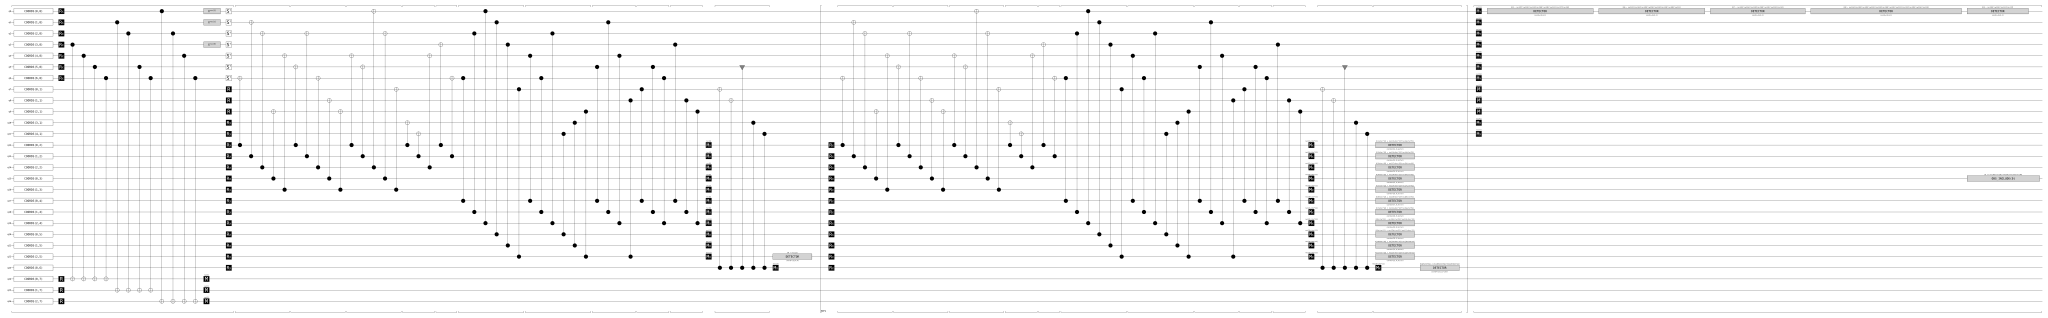

In [6]:
# Steane Ȳ single-PPM circuit (split X/Z/Y schedule).
s_x = np.asarray(steane.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
s_z = np.asarray(steane.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
s_yg = build_y_gadget(steane, x=s_x, z=s_z)
build_single_y_ppm_circuit(s_yg, rounds=3, data_init="Y+", force_obs0=True).diagram("timeline-svg")

In [7]:
# Ȳ truth table: the six logical Pauli eigenstates through the Ȳ measurement.
# |Ȳ±⟩ = S̄|X̄±⟩ read deterministically (on Steane transversal S^7 = logical S†);
# X̄/Z̄ eigenstates give genuine 50/50 (Ȳ ⟂ X̄, Z̄).
print(f"{'data_init':>10} | {'state':>6} | {'P(obs0=1)':>10} | outcome")
ok_all = True
for di, name, det in [
    ("Y+", "|Ȳ+⟩", True),
    ("Y-", "|Ȳ-⟩", True),
    ("X+", "|+̄⟩", False),
    ("X-", "|-̄⟩", False),
    ("Z+", "|0̄⟩", False),
    ("Z-", "|1̄⟩", False),
]:
    circ = build_single_y_ppm_circuit(s_yg, rounds=3, data_init=di, force_obs0=True)
    p = float(raw_observables(circ, SHOTS)[:, 0].mean())
    if det:
        ok = p in (0.0, 1.0)
        outcome = f"deterministic → Ȳ = {'+1' if p < 0.5 else '-1'}"
    else:
        ok = 0.4 < p < 0.6
        outcome = "random 50/50 (Ȳ ⟂ prep)"
    ok_all &= ok
    print(f"{di:>10} | {name:>6} | {p:>10.3f} | {outcome}")
assert ok_all, "Ȳ truth table failed"
print("\n✓ Ȳ deterministic on |Ȳ±⟩, 50/50 on X̄/Z̄ eigenstates")

 data_init |  state |  P(obs0=1) | outcome
        Y+ |   |Ȳ+⟩ |      0.000 | deterministic → Ȳ = +1
        Y- |   |Ȳ-⟩ |      1.000 | deterministic → Ȳ = -1
        X+ |   |+̄⟩ |      0.497 | random 50/50 (Ȳ ⟂ prep)
        X- |   |-̄⟩ |      0.489 | random 50/50 (Ȳ ⟂ prep)
        Z+ |   |0̄⟩ |      0.502 | random 50/50 (Ȳ ⟂ prep)
        Z- |   |1̄⟩ |      0.500 | random 50/50 (Ȳ ⟂ prep)

✓ Ȳ deterministic on |Ȳ±⟩, 50/50 on X̄/Z̄ eigenstates


## §2 Joint-PPM — Steane × Steane

Observable layout: obs = [block logical 1, block logical 2, joint parity L].

merged joint code: [[21, 1]]


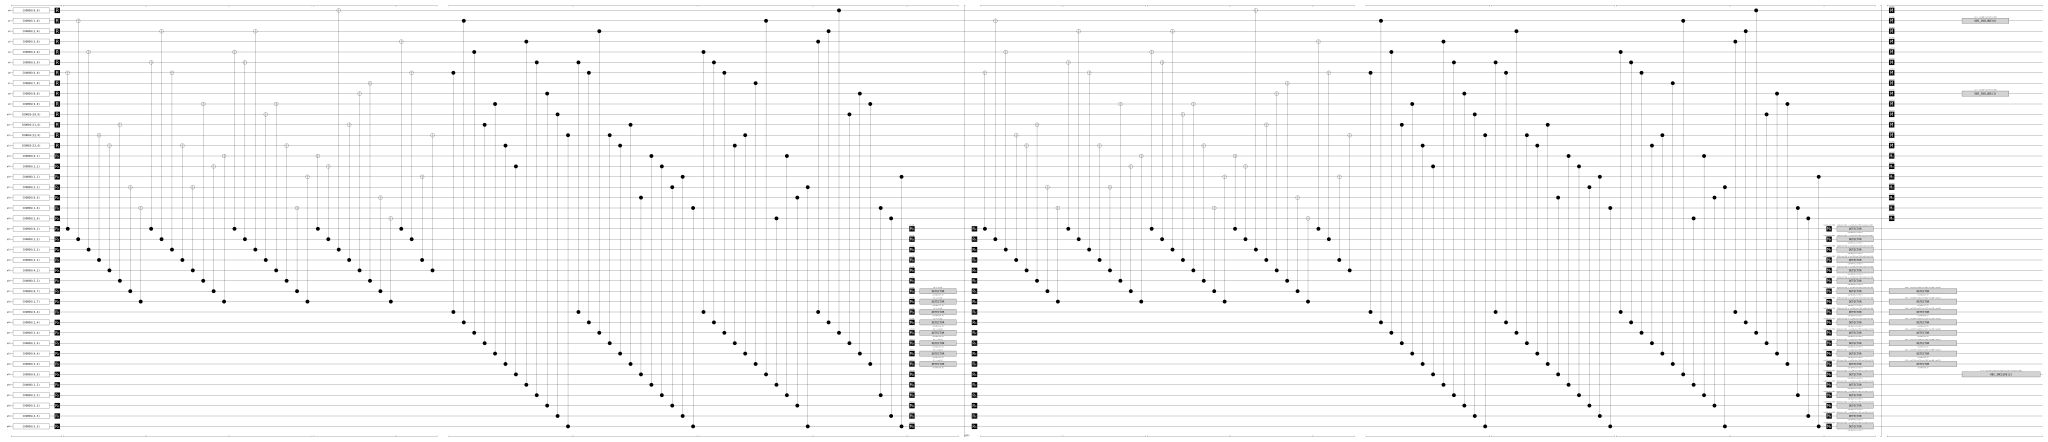

In [8]:
# Joint Z̄₁⊗Z̄₂ on two Steane blocks: same 6 lanes per block, concatenated,
# plus a 7th lane (y=6) for the bridge qubits joining the two supports.
c1, c2 = codes.SteaneCode(), codes.SteaneCode()
z1 = np.asarray(c1.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
z2 = np.asarray(c2.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
gz1 = build_gadget(c1, z1, basis=Pauli.Z)
gz2 = build_gadget(c2, z2, basis=Pauli.Z)
bridge_z = build_bridge(gz1, gz2)
circuit_zz, merged_zz = build_joint_ppm_circuit(gz1, gz2, bridge_z, rounds=3, noise_model=None)
print(f"merged joint code: [[{merged_zz.num_qudits}, {merged_zz.dimension}]]")
circuit_zz.diagram("timeline-svg")

merged joint code: [[23, 1]]


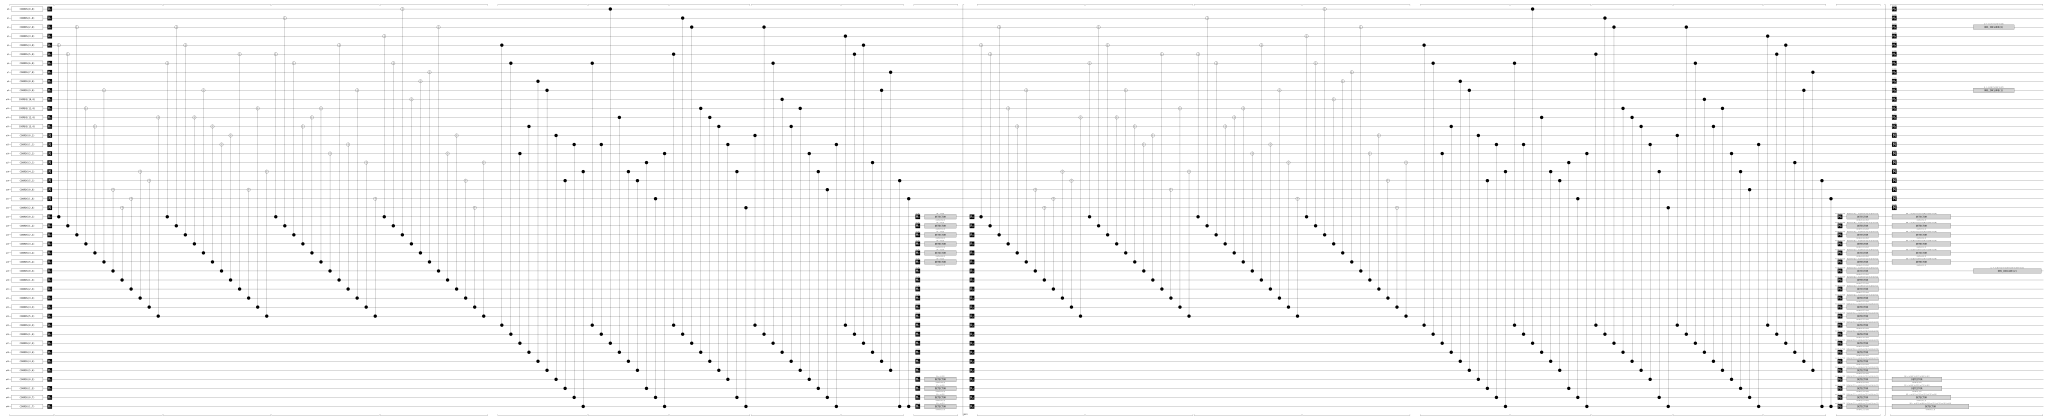

In [9]:
# Joint X̄₁⊗X̄₂ — the X-basis dual of the same construction.
x1 = np.asarray(c1.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
x2 = np.asarray(c2.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
gx1 = build_gadget(c1, x1, basis=Pauli.X)
gx2 = build_gadget(c2, x2, basis=Pauli.X)
bridge_x = build_bridge(gx1, gx2)
circuit_xx, merged_xx = build_joint_ppm_circuit(gx1, gx2, bridge_x, rounds=3, noise_model=None)
print(f"merged joint code: [[{merged_xx.num_qudits}, {merged_xx.dimension}]]")
circuit_xx.diagram("timeline-svg")

In [10]:
# Joint truth tables: the parity column obs2 = s₁ ⊕ s₂ is deterministic on every
# product of eigenstates; obs0/obs1 recover the individual block logicals.
SHOTS_JOINT = 1000
for basis, (ga, gb, br) in ((Pauli.Z, (gz1, gz2, bridge_z)), (Pauli.X, (gx1, gx2, bridge_x))):
    states = ("0", "1") if basis is Pauli.Z else ("+", "-")
    minus = states[1]
    print(f"measure {basis}̄ ⊗ {basis}̄ :")
    print(f"{'state':>12} | expected parity | obs2 frac=1 | ok")
    for s1 in states:
        for s2 in states:
            expected = float(s1 != s2)
            circ, _ = build_joint_ppm_circuit(
                ga, gb, br, rounds=3, noise_model=None,
                data_init=(
                    logical_state_init(c1, s1, log_idx=0),
                    logical_state_init(c2, s2, log_idx=0),
                ),
            )
            obs = raw_observables(circ, SHOTS_JOINT)
            rate = float(obs[:, 2].mean())
            blocks_ok = (
                float(obs[:, 0].mean()) == float(s1 == minus)
                and float(obs[:, 1].mean()) == float(s2 == minus)
                and bool(((obs[:, 0] ^ obs[:, 1]) == obs[:, 2]).all())
            )
            ok = rate == expected and blocks_ok
            print(f"{'|' + s1 + '⟩|' + s2 + '⟩':>12} | {expected:>15.0%} | {rate:>11.2%} | {'✓' if ok else '✗'}")
            assert ok, f"basis={basis} state=({s1},{s2})"
    print()
print("✓ joint Z̄⊗Z̄ and X̄⊗X̄ parities match s₁⊕s₂ deterministically")

measure Z̄ ⊗ Z̄ :
       state | expected parity | obs2 frac=1 | ok
      |0⟩|0⟩ |              0% |       0.00% | ✓
      |0⟩|1⟩ |            100% |     100.00% | ✓
      |1⟩|0⟩ |            100% |     100.00% | ✓
      |1⟩|1⟩ |              0% |       0.00% | ✓

measure X̄ ⊗ X̄ :
       state | expected parity | obs2 frac=1 | ok
      |+⟩|+⟩ |              0% |       0.00% | ✓
      |+⟩|-⟩ |            100% |     100.00% | ✓
      |-⟩|+⟩ |            100% |     100.00% | ✓
      |-⟩|-⟩ |              0% |       0.00% | ✓

✓ joint Z̄⊗Z̄ and X̄⊗X̄ parities match s₁⊕s₂ deterministically


## §3 LER — BB [[72, 12, 6]] (gross): surgery vs memory

Surgery failure rates are averaged over X- and Z-basis initialization and
measurement experiments (Cain et al. arXiv:2603.28627 App. D): **same gadget**,
only the data init/readout basis flips (`experiment_basis`, decoupled from
`gadget.basis`). The memory baseline is averaged over the same two bases.

In [13]:
xs, ys = sympy.symbols("x y")
bbcode = codes.BBCode({xs: 6, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)
x_bbcode = np.asarray(bbcode.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
g_bbcode = build_gadget(bbcode, x_bbcode, basis=Pauli.X)

h_bbcode = cheeger_constant(g_bbcode)
print(f"code         : [[{bbcode.num_qudits}, {bbcode.dimension}]]")
print(f"Cheeger h(F) : {h_bbcode:.3f}  (Webster threshold = 1.0)")
if h_bbcode < 1.0:
    print(f"→ boosting (h < 1.0)")
    g_bbcode = boost_gadget(
        g_bbcode, method="combinatorial", target=1.0, max_extra_qubits=20, seed=3
    )
    # Cain mapping: F → incidence.
    print(
        f"→ boosted F shape: {g_bbcode.incidence.shape}, h(F_aug) = {cheeger_constant(g_bbcode):.3f}"
    )
else:
    print(f"→ h ≥ 1.0, no boost needed")

code         : [[72, 12]]
Cheeger h(F) : 1.000  (Webster threshold = 1.0)
→ h ≥ 1.0, no boost needed


In [17]:
LER_ROUNDS = 9
LER_P_VALUES = list(np.linspace(0.002, 0.005, 5))
LER_MAX_SHOTS = 100_00
LER_MAX_ERRORS = 100
LER_NUM_WORKERS = 4

tasks = []
for p in LER_P_VALUES:
    noise = DepolarizingNoiseModel(p, include_idling_error=False)
    for eb in (Pauli.X, Pauli.Z):
        surg = build_single_ppm_circuit(
            g_bbcode, rounds=LER_ROUNDS, experiment_basis=eb, noise_model=noise, single_sector=True
        )
        tasks.append(
            sinter.Task(
                circuit=keep_only_observable(surg, keep_idx=0),
                json_metadata={"p": float(p), "kind": "surgery", "eb": eb.name},
            )
        )
        mem = circuits.get_memory_experiment(
            bbcode, basis=eb, num_rounds=LER_ROUNDS, noise_model=noise
        )
        tasks.append(
            sinter.Task(
                circuit=keep_only_observable(mem, keep_idx=0),
                json_metadata={"p": float(p), "kind": "memory", "eb": eb.name},
            )
        )

decoder = decoders.SinterDecoder(
    with_BP_LSD=True, max_iter=100, bp_method="ms", lsd_method="lsd_e", lsd_order=5
)

print(
    f"sweeping p ∈ [{LER_P_VALUES[0]:.4f}, {LER_P_VALUES[-1]:.4f}] × (X, Z) experiments "
    f"({len(tasks)} tasks, max_shots={LER_MAX_SHOTS}, max_errors={LER_MAX_ERRORS}, BP+LSD)"
)
t0 = time.time()
results = sinter.collect(
    tasks=tasks,
    decoders=["custom"],
    custom_decoders={"custom": decoder},
    num_workers=LER_NUM_WORKERS,
    max_shots=LER_MAX_SHOTS,
    max_errors=LER_MAX_ERRORS,
    print_progress=True,
)
print(f"collected {len(results)} task results in {time.time() - t0:.1f}s")

Starting 4 workers...


sweeping p ∈ [0.0020, 0.0050] × (X, Z) experiments (20 tasks, max_shots=10000, max_errors=100, BP+LSD)


20 tasks left:
  workers decoder eta shots_left errors_left json_metadata              
        1  custom   ?      10000         100 p=0.002,kind=surgery,eb=X  
        1  custom   ?      10000         100 p=0.002,kind=memory,eb=X   
        1  custom   ?      10000         100 p=0.002,kind=surgery,eb=Z  
        1  custom <1m       9983         100 p=0.002,kind=memory,eb=Z   
        0  custom ?·∞      10000         100 p=0.00275,kind=surgery,eb=X
        0  custom ?·∞      10000         100 p=0.00275,kind=memory,eb=X 
        0  custom ?·∞      10000         100 p=0.00275,kind=surgery,eb=Z
        0  custom ?·∞      10000         100 p=0.00275,kind=memory,eb=Z 
        0  custom ?·∞      10000         100 p=0.0035,kind=surgery,eb=X 
        0  custom ?·∞      10000         100 p=0.0035,kind=memory,eb=X  
        0  custom ?·∞      10000         100 p=0.0035,kind=surgery,eb=Z 
        0  custom ?·∞      10000         100 p=0.0035,kind=memory,eb=Z  
        0  custom ?·∞      10000    

collected 20 task results in 83.9s


In [20]:
# Per-basis LERs and the X/Z average actually reported.
by_eb = {}
for r in results:
    m = r.json_metadata
    by_eb[(m["kind"], m["p"], m["eb"])] = r.errors / max(r.shots, 1)

surgery_lers = {p: float(np.mean([by_eb[("surgery", p, "X")], by_eb[("surgery", p, "Z")]])) for p in LER_P_VALUES}
memory_lers = {p: float(np.mean([by_eb[("memory", p, "X")], by_eb[("memory", p, "Z")]])) for p in LER_P_VALUES}

print(f"{'p':>8} | {'surg X':>8} {'surg Z':>8} {'surg avg':>8} | {'mem X':>8} {'mem Z':>8} {'mem avg':>8}")
print(f"{'-' * 8} | {'-' * 26} | {'-' * 26}")
for p in sorted(LER_P_VALUES):
    print(
        f"{p:>8.4f} | {by_eb[('surgery', p, 'X')]:>8.4f} {by_eb[('surgery', p, 'Z')]:>8.4f} {surgery_lers[p]:>8.4f} | "
        f"{by_eb[('memory', p, 'X')]:>8.4f} {by_eb[('memory', p, 'Z')]:>8.4f} {memory_lers[p]:>8.4f}"
    )

       p |   surg X   surg Z surg avg |    mem X    mem Z  mem avg
-------- | -------------------------- | --------------------------
  0.0020 |   0.0009   0.0032   0.0021 |   0.0006   0.0013   0.0009
  0.0027 |   0.0027   0.0128   0.0078 |   0.0027   0.0035   0.0031
  0.0035 |   0.0071   0.0345   0.0208 |   0.0135   0.0118   0.0126
  0.0043 |   0.0150   0.0590   0.0370 |   0.0225   0.0350   0.0287
  0.0050 |   0.0291   0.1044   0.0668 |   0.0553   0.0580   0.0566


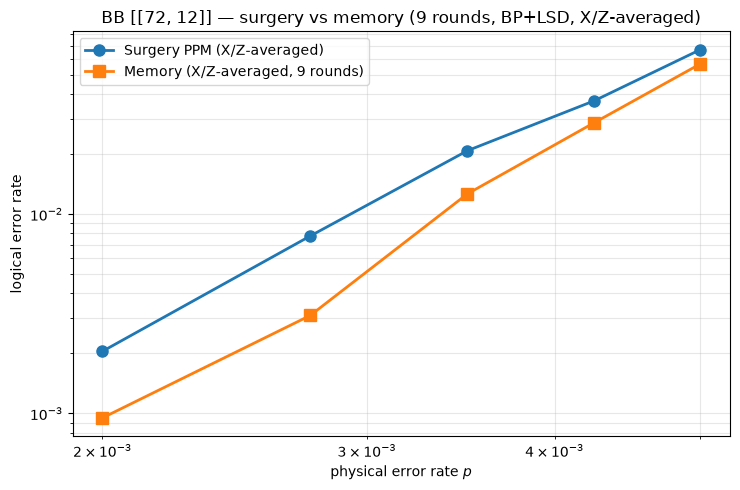

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ps_sorted = sorted(LER_P_VALUES)
ax.loglog(
    ps_sorted,
    [surgery_lers[p] for p in ps_sorted],
    "o-",
    label="Surgery PPM (X/Z-averaged)",
    markersize=8,
    linewidth=2,
)
ax.loglog(
    ps_sorted,
    [memory_lers[p] for p in ps_sorted],
    "s-",
    label=f"Memory (X/Z-averaged, {LER_ROUNDS} rounds)",
    markersize=8,
    linewidth=2,
)
ax.set_xlabel("physical error rate $p$")
ax.set_ylabel("logical error rate")
ax.set_title(
    f"BB [[{bbcode.num_qudits}, {bbcode.dimension}]] — surgery vs memory "
    f"({LER_ROUNDS} rounds, BP+LSD, X/Z-averaged)"
)
ax.legend(loc="upper left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## §4 LER — Cain `bb_18` [[248, 10, 18]]: surgery vs idling

Cain et al. arXiv:2603.28627 App. A Eq. A11 code. The low-weight canonical
logical basis is computed by `symplectic_logical_basis` (Leon/QDistRnd
random-window sampler + symplectic Gram-Schmidt) and installed via
`set_logical_ops_xz`; the gadget measures the weight-20 Z̄ and reproduces Cain
Table III (|Q'|, |S_X'|, |S_Z'|) = (39, 20, 20). LER: τ_s = 15 surgery rounds vs
a 9-round idling baseline, per-cycle (Ext. Data Fig. 1b convention), both
X/Z-averaged; noise = uniform depolarizing on gates/preps/measurements, **no
idling error** (App. D).

In [22]:
# Cain App. A Eq. A11 bb_18 (l=31, m=4): a = 1 + x⁶y + x²⁷, b = y² + x¹⁵y³ + x²⁴.
xs, ys = sympy.symbols("x y")
bb18 = codes.BBCode((31, 4), 1 + xs**6 * ys + xs**27, ys**2 + xs**15 * ys**3 + xs**24)
assert (bb18.num_qubits, bb18.dimension) == (248, 10)

# Low-weight canonical logical basis (Cain's profile: ten X̄ at wt 18; nine Z̄ at
# wt 18 + one at wt 20 — the single wt-20 is the irreducible symplectic excess).
rng_basis = np.random.default_rng(1)  # fixed seed → reproducible basis, ~1 min
Lx_bb18, Lz_bb18 = symplectic_logical_basis(bb18, distance=18, rng=rng_basis, verbose=True, optimize=Pauli.Z)
# assert sorted(int(v.sum()) for v in Lx_bb18) == [18] * 10
# assert sorted(int(v.sum()) for v in Lz_bb18) == [18] * 9 + [20]
bb18.set_logical_ops_xz(Lx_bb18, Lz_bb18)
print("installed on bb18: ten X̄ @ wt 18; nine Z̄ @ wt 18 + one @ wt 20")

# The gadget measures the wt-20 Z̄ directly on bb18 (basis=Pauli.Z below); the
# installed low-weight basis supplies the experiment observables.
idx_20 = int(np.argmax([int(v.sum()) for v in Lx_bb18]))
vec_20 = np.asarray(Lx_bb18[idx_20]).astype(np.uint8)

  round 1: |Z<=46|=6000  |X<=46|=6000
  round 2: |Z<=46|=6000  |X<=46|=6000
  round 3: |Z<=46|=6000  |X<=46|=6000
  best: Z weights [18, 18, 18, 18, 18, 18, 18, 18, 18, 18]
        X weights [18, 18, 18, 18, 18, 18, 18, 18, 18, 20]
installed on bb18: ten X̄ @ wt 18; nine Z̄ @ wt 18 + one @ wt 20


In [ ]:
comm_tab = np.zeros((10, 10), dtype=np.uint8)
for i in range(10):
    for j in range(10):
        comm_tab[i,j] = (Lx_bb18[i] @ Lz_bb18[j].T % 2 )
print(comm_tab)

[[1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 1]]


In [23]:

print(sorted(int(v.sum()) for v in Lx_bb18))
print(sorted(int(v.sum()) for v in Lz_bb18))

bb18.set_logical_ops_xz(Lx_bb18, Lz_bb18)

# The gadget measures the wt-20 Z̄ directly on bb18 (basis=Pauli.Z below); the
# installed low-weight basis supplies the experiment observables.
idx_20 = int(np.argmax([int(v.sum()) for v in Lx_bb18]))
vec_20 = np.asarray(Lx_bb18[idx_20]).astype(np.uint8)
print(vec_20.sum())

[18, 18, 18, 18, 18, 18, 18, 18, 18, 20]
[18, 18, 18, 18, 18, 18, 18, 18, 18, 18]
20


In [32]:
# Verify the logical is checked

# new_Lx_bb18 = Lx_bb18.copy()
# new_Lx_bb18[0, 3] = (new_Lx_bb18[0, 3] + 1) % 2
# bb18.set_logical_ops_xz(new_Lx_bb18, Lz_bb18)

idx_20 = int(np.argmax([int(v.sum()) for v in Lx_bb18]))
vec_20 = np.sum([Lx_bb18[i] for i in range(10) if i != idx_20], axis=0) % 2
np.sum(vec_20 % 2 )

np.uint64(88)

In [35]:
# build_gadget uses the edge-expanded homological construction (arXiv:2410.02753
# Alg 1/2/3) by default: Cheeger ≥ 1 AND a low-weight ∂0 (cellulated to the native
# check weight) directly, so the old minimal_z_checks / boost_gadget path is gone.
# g_bb IS the final gadget.
g_bb = build_gadget(bb18, vec_20, basis=Pauli.X)
g_bb_boosted = g_bb  # alias for the LER cells below

# S_X' / S_Z' = new X- / Z-type stabilizers = the rows of H̃ beyond the native checks.
# Counting new rows is basis-agnostic (support ↔ partial_0 swap roles with the basis).
n_x, n_z = bb18.matrix_x.shape[0], bb18.matrix_z.shape[0]
HX_m = np.asarray(g_bb.HX_merged).astype(int)
HZ_m = np.asarray(g_bb.HZ_merged).astype(int)
s_x, s_z = HX_m.shape[0] - n_x, HZ_m.shape[0] - n_z
triple = (len(g_bb.Q_prime), s_x, s_z)                       # (|Q'|, |S_X'|, |S_Z'|)
degree = max(int(HX_m.sum(1).max()), int(HZ_m.sum(1).max()))
print(
    f"bb_18 [[{bb18.num_qudits}, {bb18.dimension}]] edge-expanded gadget "
    f"(measuring wt-{int(vec_20.sum())} {g_bb.basis.name}̄): "
    f"(|Q'|, |S_X'|, |S_Z'|) = {triple}, merged degree = {degree}"
)
# Where the weight lives — native checks vs the new S_X' / S_Z' rows. For basis=X the
# new X-checks are [f1ᵀ|∂1] with weight = support-vertex-degree + 1, so a heavy/high-
# degree logical inflates S_X'. Measure a lighter (weight-18) logical to avoid this.
print(
    f"  max row weight — H_X {int(HX_m[:n_x].sum(1).max())}, "
    f"S_X' {int(HX_m[n_x:].sum(1).max()) if s_x else 0} | "
    f"H_Z {int(HZ_m[:n_z].sum(1).max())}, "
    f"S_Z' {int(HZ_m[n_z:].sum(1).max()) if s_z else 0}"
)
print("(Cain Table III old-construction reference: (189, 104, 86), merged degree 9.)")

bb_18 [[248, 10]] edge-expanded gadget (measuring wt-88 X̄): (|Q'|, |S_X'|, |S_Z'|) = (190, 88, 98), merged degree = 8
  max row weight — H_X 6, S_X' 8 | H_Z 8, S_Z' 6
(Cain Table III old-construction reference: (189, 104, 86), merged degree 9.)


In [ ]:
# build_gadget uses the edge-expanded homological construction (arXiv:2410.02753
# Alg 1/2/3) by default: Cheeger ≥ 1 AND a low-weight ∂0 (cellulated to the native
# check weight) directly, so the old minimal_z_checks / boost_gadget path is gone.
# g_bb IS the final gadget.
g_bb = build_gadget(bb18, vec_20, basis=Pauli.X)
g_bb_boosted = g_bb  # alias for the LER cells below

# S_X' / S_Z' = new X- / Z-type stabilizers = the rows of H̃ beyond the native checks.
# Counting new rows is basis-agnostic (support ↔ partial_0 swap roles with the basis).
n_x, n_z = bb18.matrix_x.shape[0], bb18.matrix_z.shape[0]
HX_m = np.asarray(g_bb.HX_merged).astype(int)
HZ_m = np.asarray(g_bb.HZ_merged).astype(int)
s_x, s_z = HX_m.shape[0] - n_x, HZ_m.shape[0] - n_z
triple = (len(g_bb.Q_prime), s_x, s_z)                       # (|Q'|, |S_X'|, |S_Z'|)
degree = max(int(HX_m.sum(1).max()), int(HZ_m.sum(1).max()))
print(
    f"bb_18 [[{bb18.num_qudits}, {bb18.dimension}]] edge-expanded gadget "
    f"(measuring wt-{int(vec_20.sum())} {g_bb.basis.name}̄): "
    f"(|Q'|, |S_X'|, |S_Z'|) = {triple}, merged degree = {degree}"
)
# Where the weight lives — native checks vs the new S_X' / S_Z' rows. For basis=X the
# new X-checks are [f1ᵀ|∂1] with weight = support-vertex-degree + 1, so a heavy/high-
# degree logical inflates S_X'. Measure a lighter (weight-18) logical to avoid this.
print(
    f"  max row weight — H_X {int(HX_m[:n_x].sum(1).max())}, "
    f"S_X' {int(HX_m[n_x:].sum(1).max()) if s_x else 0} | "
    f"H_Z {int(HZ_m[:n_z].sum(1).max())}, "
    f"S_Z' {int(HZ_m[n_z:].sum(1).max()) if s_z else 0}"
)
print("(Cain Table III old-construction reference: (39, 20, 20), merged degree 7.)")

In [ ]:
import numpy as np
n = bb18.num_qudits
HX = np.asarray(g_bb.HX_merged).astype(int)   # basis=Z: [[H_X | f0], [0 | ∂0]]
HZ = np.asarray(g_bb.HZ_merged).astype(int)   # basis=Z: [[H_Z | 0], [f1ᵀ | ∂1]]
p0 = np.asarray(g_bb.partial_0).astype(int)
inc = np.asarray(g_bb.incidence).astype(int)  # (edges × vertices)
native = int(np.asarray(bb18.matrix_x).sum(1).max())
print("∂0 max weight:", int(p0.sum(1).max()) if p0.shape[0] else 0, " (cellulate target =", native, ")")
print("HX_merged: native[:, :n] max", int(HX[:, :n].sum(1).max()), " ancilla[:, n:] max", int(HX[:,
n:].sum(1).max()))
print("HZ_merged: native[:, :n] max", int(HZ[:, :n].sum(1).max()), " ancilla[:, n:] max", int(HZ[:,
n:].sum(1).max()))
print("vertex degrees (edges per support qubit), top 8:", sorted(inc.sum(0), reverse=True)[:8])


∂0 max weight: 5  (cellulate target = 6 )
HX_merged: native[:, :n] max 6  ancilla[:, n:] max 4
HZ_merged: native[:, :n] max 6  ancilla[:, n:] max 5
vertex degrees (edges per support qubit), top 8: [np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4)]


In [ ]:
xs, ys = sympy.symbols("x y")
bbcode = codes.BBCode({xs: 6, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)
Lx_bb, Lz_bb = symplectic_logical_basis(bbcode, distance=6, rng=rng_basis, verbose=True, optimize=Pauli.Z)
x_bbcode = Lx_bb[-1,:]

  round 1: |Z<=46|=6000  |X<=46|=6000
  round 2: |Z<=46|=6000  |X<=46|=6000
  round 3: |Z<=46|=6000  |X<=46|=6000
  best: Z weights [6, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 8]
        X weights [6, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 8]


In [ ]:
# BP 收敛率探针：和 LER sweep 同电路、同 decoder，逐 shot 读 bp.converge / bp.iter。
def bp_convergence_report(circuit, decoder_config, shots=300, seed=0):
    compiled = decoders.SinterDecoder(**decoder_config).compile_decoder_for_dem(
        circuit.detector_error_model())
    bp = compiled.decoder                      # ldpc.bplsd_decoder.BpLsdDecoder
    obs_mat = compiled.dem_arrays.observable_flip_matrix

    dets, obs = circuit.compile_detector_sampler(seed=seed).sample(
        shots, separate_observables=True)
    conv = np.zeros(shots, dtype=bool)
    iters = np.zeros(shots, dtype=int)
    fail = np.zeros(shots, dtype=bool)
    for i, syndrome in enumerate(dets.astype(np.uint8)):
        pred_err = bp.decode(syndrome)         # .converge/.iter 反映最近一次 decode
        conv[i], iters[i] = bp.converge, bp.iter
        fail[i] = bool(np.any((obs_mat @ pred_err) % 2 != obs[i]))
    print(f"BP 收敛率: {conv.mean():.1%}   平均迭代: {iters.mean():.1f}/{decoder_config.get('max_iter')}")
    print(f"LER 总体: {fail.mean():.4f}"
          f" | BP收敛的 shots: {fail[conv].mean() if conv.any() else float('nan'):.4f}"
          f" | 不收敛(走LSD)的 shots: {fail[~conv].mean() if (~conv).any() else float('nan'):.4f}")


DECODER_CFG_BB18 = dict(with_BP_LSD=True, max_iter=100, bp_method="ms",
                        ms_scaling_factor=0.0, schedule="serial",
                        lsd_method="lsd_e", lsd_order=5)

probe_noise = DepolarizingNoiseModel(0.003, include_idling_error=False)
probe_circuits = {
    "surgery (τ_s=15, single_sector)": keep_only_observable(
        build_single_ppm_circuit(g_bb_boosted, rounds=15, experiment_basis=Pauli.X,
                                 noise_model=probe_noise, single_sector=True),
        keep_idx=0),
    "memory (9 rounds)": keep_only_observable(
        circuits.get_memory_experiment(bb18, basis=Pauli.Z, num_rounds=9,
                                       noise_model=probe_noise),
        keep_idx=0),
}
for probe_name, probe_circ in probe_circuits.items():
    print(f"— {probe_name} —")
    bp_convergence_report(probe_circ, DECODER_CFG_BB18, shots=10)
    print()

— surgery (τ_s=15, single_sector) —
BP 收敛率: 0.0%   平均迭代: 100.0/100
LER 总体: 0.3000 | BP收敛的 shots: nan | 不收敛(走LSD)的 shots: 0.3000

— memory (9 rounds) —
BP 收敛率: 0.0%   平均迭代: 100.0/100
LER 总体: 0.5000 | BP收敛的 shots: nan | 不收敛(走LSD)的 shots: 0.5000



In [ ]:
LER_ROUNDS_SURGERY_BB18 = 15  # τ_s for surgery PPM (Cain Ext. Data Fig. 1b)
LER_ROUNDS_MEMORY_BB18 = 9  # cycles for the idling memory baseline
LER_P_VALUES_BB18 = [0.003, 0.004, 0.005]
LER_MAX_SHOTS_BB18 = 10_000
LER_MAX_ERRORS_BB18 = 100
LER_NUM_WORKERS_BB18 = 4

tasks_bb18 = []
for p in LER_P_VALUES_BB18:
    noise = DepolarizingNoiseModel(p, include_idling_error=False)
    for eb in (Pauli.X, Pauli.Z):
        surg = build_single_ppm_circuit(
            g_bb_boosted, rounds=LER_ROUNDS_SURGERY_BB18, experiment_basis=eb, noise_model=noise, single_sector=True
        )
        tasks_bb18.append(
            sinter.Task(
                circuit=keep_only_observable(surg, keep_idx=0),
                json_metadata={"p": float(p), "kind": "surgery", "eb": eb.name},
            )
        )
        mem = circuits.get_memory_experiment(
            bb18, basis=eb, num_rounds=LER_ROUNDS_MEMORY_BB18, noise_model=noise
        )
        tasks_bb18.append(
            sinter.Task(
                circuit=keep_only_observable(mem, keep_idx=0),
                json_metadata={"p": float(p), "kind": "memory", "eb": eb.name},
            )
        )

decoder_bb18 = decoders.SinterDecoder(**DECODER_CFG_BB18)

print(f"sweep p ∈ {LER_P_VALUES_BB18} × (X, Z) experiments ({len(tasks_bb18)} tasks)")
print(f"  max_shots={LER_MAX_SHOTS_BB18:,}  max_errors={LER_MAX_ERRORS_BB18}  workers={LER_NUM_WORKERS_BB18}")
t0 = time.time()
results_bb18 = sinter.collect(
    tasks=tasks_bb18,
    decoders=["custom"],
    custom_decoders={"custom": decoder_bb18},
    num_workers=LER_NUM_WORKERS_BB18,
    max_shots=LER_MAX_SHOTS_BB18,
    max_errors=LER_MAX_ERRORS_BB18,
    print_progress=True
)
print(f"collected {len(results_bb18)} task results in {time.time() - t0:.1f}s")

Starting 4 workers...


sweep p ∈ [0.003, 0.004, 0.005] × (X, Z) experiments (12 tasks)
  max_shots=10,000  max_errors=100  workers=4


12 tasks left:
  workers decoder eta shots_left errors_left json_metadata            
        1  custom   ?      10000         100 p=0.003,kind=surgery,eb=X
        1  custom  2m       9999         100 p=0.003,kind=memory,eb=X 
        1  custom   ?      10000         100 p=0.003,kind=surgery,eb=Z
        1  custom   ?      10000         100 p=0.003,kind=memory,eb=Z 
        0  custom ?·∞      10000         100 p=0.004,kind=surgery,eb=X
        0  custom ?·∞      10000         100 p=0.004,kind=memory,eb=X 
        0  custom ?·∞      10000         100 p=0.004,kind=surgery,eb=Z
        0  custom ?·∞      10000         100 p=0.004,kind=memory,eb=Z 
        0  custom ?·∞      10000         100 p=0.005,kind=surgery,eb=X
        0  custom ?·∞      10000         100 p=0.005,kind=memory,eb=X 
        0  custom ?·∞      10000         100 p=0.005,kind=surgery,eb=Z
        0  custom ?·∞      10000         100 p=0.005,kind=memory,eb=Z 
12 tasks left:
  workers decoder eta shots_left errors_left js

collected 12 task results in 2605.8s


In [ ]:
# Total LER (over the experiment's rounds) → per-cycle LER, per basis, then X/Z-average.
per_cycle = {}
for r in results_bb18:
    m = r.json_metadata
    rounds_kind = LER_ROUNDS_SURGERY_BB18 if m["kind"] == "surgery" else LER_ROUNDS_MEMORY_BB18
    ler_total = r.errors / max(r.shots, 1)
    per_cycle[(m["kind"], m["p"], m["eb"])] = (
        1 - (1 - ler_total) ** (1 / rounds_kind) if ler_total < 1 else 1.0
    )

surgery_lers_bb18 = {
    p: float(np.mean([per_cycle[("surgery", p, "X")], per_cycle[("surgery", p, "Z")]]))
    for p in LER_P_VALUES_BB18
}
memory_lers_bb18 = {
    p: float(np.mean([per_cycle[("memory", p, "X")], per_cycle[("memory", p, "Z")]]))
    for p in LER_P_VALUES_BB18
}

print(f"{'p':>8} | {'surg X':>9} {'surg Z':>9} {'surg avg':>9} | {'mem X':>9} {'mem Z':>9} {'mem avg':>9}   (per-cycle)")
print(f"{'-' * 8} | {'-' * 29} | {'-' * 29}")
for p in sorted(LER_P_VALUES_BB18):
    print(
        f"{p:>8.4f} | {per_cycle[('surgery', p, 'X')]:>9.2e} {per_cycle[('surgery', p, 'Z')]:>9.2e} {surgery_lers_bb18[p]:>9.2e} | "
        f"{per_cycle[('memory', p, 'X')]:>9.2e} {per_cycle[('memory', p, 'Z')]:>9.2e} {memory_lers_bb18[p]:>9.2e}"
    )

       p |    surg X    surg Z  surg avg |     mem X     mem Z   mem avg   (per-cycle)
-------- | ----------------------------- | -----------------------------
  0.0030 |  1.33e-05  4.67e-05  3.00e-05 |  0.00e+00  1.11e-05  5.56e-06
  0.0040 |  4.00e-05  2.40e-04  1.40e-04 |  3.33e-05  3.33e-05  3.33e-05
  0.0050 |  2.07e-04  1.28e-03  7.42e-04 |  2.67e-04  3.23e-04  2.95e-04


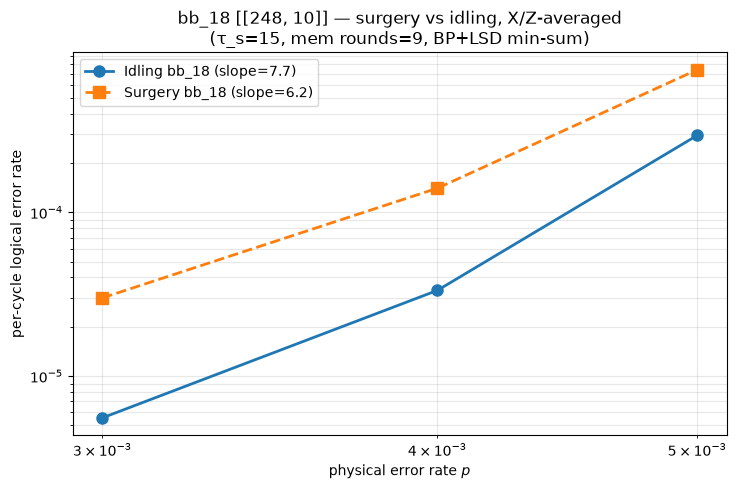

In [ ]:
ps_sorted = sorted(LER_P_VALUES_BB18)
surg_y = np.array([surgery_lers_bb18[p] for p in ps_sorted])
mem_y = np.array([memory_lers_bb18[p] for p in ps_sorted])


def _fit_log_slope(ps, ys):
    """log-log linear fit. Returns (slope, intercept_at_log_p=0)."""
    mask = ys > 0
    if mask.sum() < 2:
        return float("nan"), float("nan")
    lp = np.log(np.array(ps)[mask])
    ly = np.log(ys[mask])
    slope, intercept = np.polyfit(lp, ly, 1)
    return float(slope), float(intercept)


surg_slope, _ = _fit_log_slope(ps_sorted, surg_y)
mem_slope, _ = _fit_log_slope(ps_sorted, mem_y)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(ps_sorted, mem_y, "o-", label=f"Idling bb_18 (slope={mem_slope:.1f})", markersize=8, linewidth=2)
ax.loglog(ps_sorted, surg_y, "s--", label=f"Surgery bb_18 (slope={surg_slope:.1f})", markersize=8, linewidth=2)
ax.set_xlabel("physical error rate $p$")
ax.set_ylabel("per-cycle logical error rate")
ax.set_title(
    f"bb_18 [[{bb18.num_qudits}, {bb18.dimension}]] — surgery vs idling, X/Z-averaged"
    f"\n(τ_s={LER_ROUNDS_SURGERY_BB18}, mem rounds={LER_ROUNDS_MEMORY_BB18}, BP+LSD min-sum)"
)
ax.legend(loc="upper left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()